In [2]:
from google.colab import files
uploaded = files.upload()

Saving cs-test.csv to cs-test.csv
Saving cs-training.csv to cs-training.csv
Saving Data Dictionary.xls to Data Dictionary.xls
Saving sampleEntry.csv to sampleEntry.csv


# ***Exploración inicial***

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seborn as sns

# Cargar el dataset de entrenamiento
df = pd.read_csv('cs-training.csv', index_col=0)

# Primeras filas
print("Shape:", df.shape)
print("\nPrimeras filas:")
df.head()

Shape: (150000, 11)

Primeras filas:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


# ***Análisis detallado de las variables***

In [4]:
# Información general del dataset
print("=== SHAPE ===")
print(df.shape)

print("\n=== TIPOS DE DATOS ===")
print(df.dtypes)

print("\n=== VALORES FALTANTES ===")
faltantes = df.isnull().sum()
porcentaje = (faltantes / len(df)) * 100
tabla_faltantes = pd.DataFrame({
    'Valores faltantes': faltantes,
    'Porcentaje %': porcentaje.round(2)
})
print(tabla_faltantes[tabla_faltantes['Valores faltantes'] > 0])

=== SHAPE ===
(150000, 11)

=== TIPOS DE DATOS ===
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

=== VALORES FALTANTES ===
                    Valores faltantes  Porcentaje %
MonthlyIncome                   29731         19.82
NumberOfDependents               3924          2.62


In [5]:
# Imputación con mediana (más robusta que la media ante outliers)
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
df['NumberOfDependents'].fillna(df['NumberOfDependents'].median(), inplace=True)

# Verificar que ya no hay faltantes
print("Faltantes después de imputación:")
print(df.isnull().sum().sum())

Faltantes después de imputación:
0


/tmp/ipykernel_423/1951639728.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
/tmp/ipykernel_423/1951639728.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

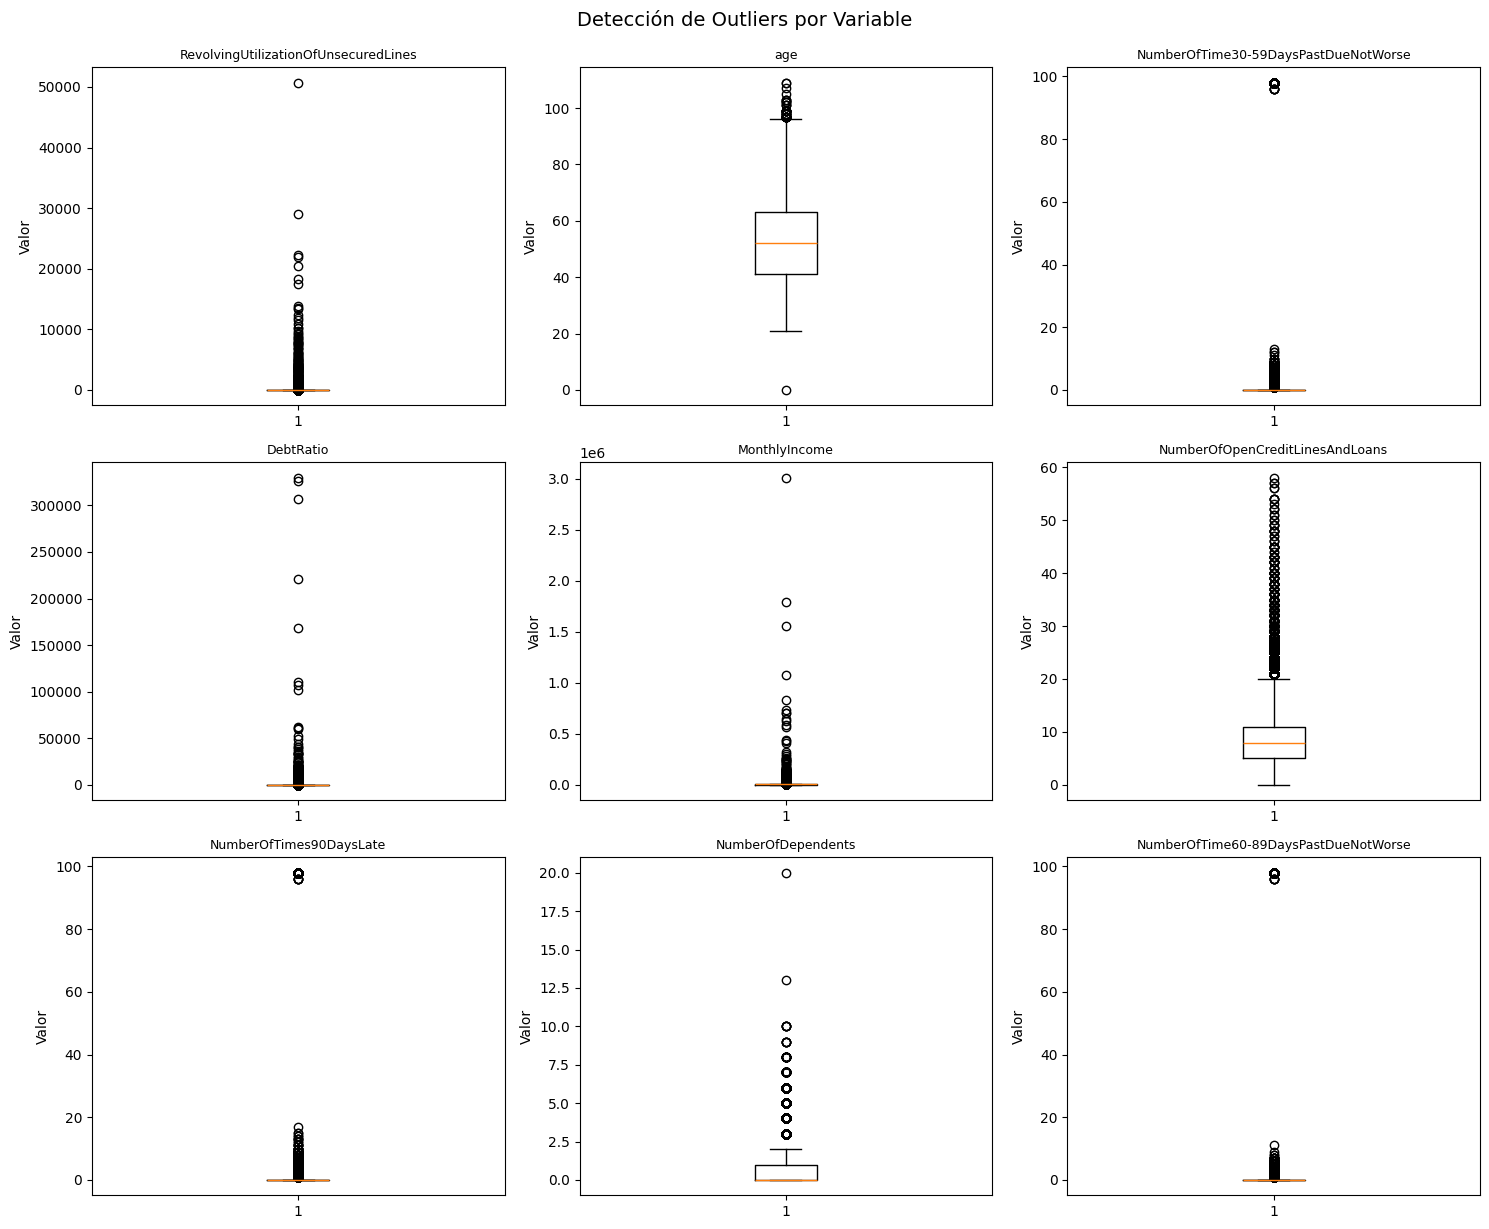

In [6]:
# Visualizar outliers con boxplots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

columnas = ['RevolvingUtilizationOfUnsecuredLines', 'age',
            'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio',
            'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
            'NumberOfTimes90DaysLate', 'NumberOfDependents',
            'NumberOfTime60-89DaysPastDueNotWorse']

for i, col in enumerate(columnas):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('Valor')

plt.tight_layout()
plt.suptitle('Detección de Outliers por Variable',
             fontsize=14, y=1.02)
plt.show()

In [7]:
# Caps de valores imposibles o extremos
# RevolvingUtilization y DebtRatio deben estar entre 0 y 1
df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)
df['DebtRatio'] = df['DebtRatio'].clip(0, 1)

# Valores 96, 97, 98 en variables de retrasos son códigos de error
for col in ['NumberOfTime30-59DaysPastDueNotWorse',
            'NumberOfTimes90DaysLate',
            'NumberOfTime60-89DaysPastDueNotWorse']:
    df[col] = df[col].replace([96, 97, 98], 0)

# Age mínima razonable = 18
df['age'] = df['age'].clip(18, 100)

# MonthlyIncome cap en percentil 99
cap_income = df['MonthlyIncome'].quantile(0.99)
df['MonthlyIncome'] = df['MonthlyIncome'].clip(0, cap_income)

print("Outliers tratados correctamente")
print("\nEstadísticas después del tratamiento:")
df.describe().round(2)

Outliers tratados correctamente

Estadísticas después del tratamiento:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00
mean,0.07,0.32,52.30,0.25,0.47,6142.45,8.45,0.09,1.02,0.06,0.74
std,0.25,0.35,14.77,0.70,0.36,3835.68,5.15,0.49,1.13,0.33,1.11
min,0.00,0.00,18.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.03,41.00,0.00,0.18,3903.00,5.00,0.00,0.00,0.00,0.00
50%,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,0.00,0.56,63.00,0.00,0.87,7400.00,11.00,0.00,2.00,0.00,1.00
max,1.00,1.00,100.00,13.00,1.00,23000.00,58.00,17.00,54.00,11.00,20.00


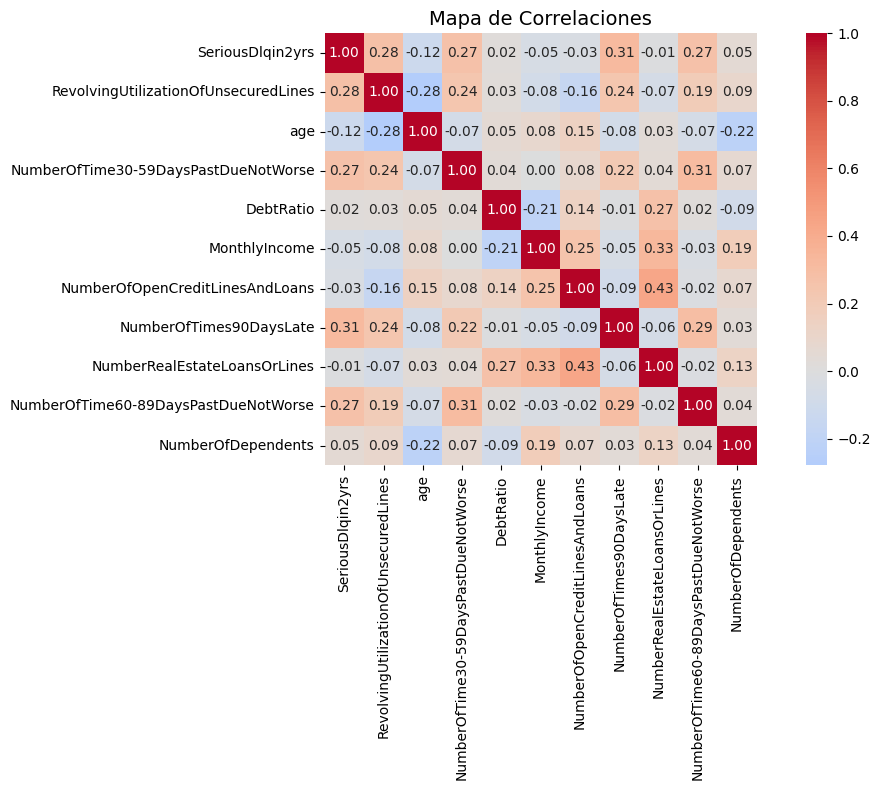


Correlación con SeriousDlqin2yrs:
SeriousDlqin2yrs                        1.000000
NumberOfTimes90DaysLate                 0.311713
RevolvingUtilizationOfUnsecuredLines    0.278096
NumberOfTime30-59DaysPastDueNotWorse    0.271411
NumberOfTime60-89DaysPastDueNotWorse    0.265594
NumberOfDependents                      0.046869
DebtRatio                               0.023156
NumberRealEstateLoansOrLines           -0.007038
NumberOfOpenCreditLinesAndLoans        -0.029669
MonthlyIncome                          -0.049790
age                                    -0.115395
Name: SeriousDlqin2yrs, dtype: float64


In [8]:
# Mapa de calor de correlaciones
plt.figure(figsize=(12, 8))
correlaciones = df.corr()

sns.heatmap(correlaciones,
            annot=True,      # muestra los números
            fmt='.2f',       # 2 decimales
            cmap='coolwarm', # azul=negativo, rojo=positivo
            center=0,
            square=True)

plt.title('Mapa de Correlaciones', fontsize=14)
plt.tight_layout()
plt.show()

# Correlaciones con la variable objetivo
print("\nCorrelación con SeriousDlqin2yrs:")
print(correlaciones['SeriousDlqin2yrs'].sort_values(ascending=False))